In [ ]:
#kütüphaneler tanımlandı
import pandas as pd
import glob
import matplotlib.pyplot as plt
import folium

In [ ]:
#datasets klasöründeki tüm csv dosyaları okunarak tek bir dataframe haline getirildi
klasor_yolu = "C:\\Users\\pc\\Documents\\ucus-analiz\\datasets\\*.csv"  # kendi klasör yoluna göre güncelle
dosyalar = glob.glob(klasor_yolu)
print(f"{len(dosyalar)} dosya bulundu")

df_listesi = [pd.read_csv(dosya) for dosya in dosyalar]
df_tam_gun = pd.concat(df_listesi, ignore_index=True)
print(df_tam_gun.shape)
df_tam_gun.head()

24 dosya bulundu


(61296085, 16)


,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact
0,1656288000,34718e,40.872940,1.922974,187.631064,245.543044,8.12800,IBE2601,False,False,False,417.0,5509.26,5814.06,1.656288e+09,1.656288e+09
1,1656288000,ac6364,33.139048,-85.526266,237.239575,337.160319,0.00000,DAL749,False,False,False,5761.0,10363.20,11003.28,1.656288e+09,1.656288e+09
2,1656288000,406471,51.908569,1.838303,169.170746,286.065061,-0.65024,TOM891,False,False,False,3541.0,5478.78,5570.22,1.656288e+09,1.656288e+09
3,1656288000,a04417,33.757187,-83.458370,132.312157,228.625465,-0.32512,N116SK,False,False,False,1716.0,7955.28,8458.20,1.656288e+09,1.656288e+09
4,1656288000,c04aa1,42.869522,-79.307939,209.512017,355.493393,-7.80288,CGCGU,False,False,False,3622.0,5859.78,6088.38,1.656288e+09,1.656288e+09


In [ ]:
#Türkiye sınırları içindeki uçuş verileri filtrelendi
df_turkiye = df_tam_gun[
    (df_tam_gun["lat"] >= 36.0) & (df_tam_gun["lat"] <= 42.0) &
    (df_tam_gun["lon"] >= 26.0) & (df_tam_gun["lon"] <= 45.0)
]
print(df_turkiye.shape)

(897996, 16)


In [ ]:
#Veri tipleri donüştürüldü ve düzenlemeler yapıldı
df_turkiye["time"] = pd.to_datetime(df_turkiye["time"], unit="s")
df_turkiye["saat"] = df_turkiye["time"].dt.hour
df_turkiye["havayolu_kodu"] = df_turkiye["callsign"].str.strip().str[:3]

In [10]:
# Zaman kaybı olmaması için (61 milyon satırlık ham veriyi tekrar işlememek için) kaydedildi
df_turkiye.to_csv("turkiye_ucus_verisi_gun.csv", index=False)
print("Kaydedildi.")

Kaydedildi.


In [ ]:
#Uçuşların saatlik dağılımı hesaplandı ve yazdırıldı
saatlik_trafik = df_turkiye.groupby("saat")["icao24"].nunique()
print(saatlik_trafik)

saat
0     151
1     174
2     193
3     221
4     271
5     324
6     321
7     354
8     367
9     364
10    386
11    399
12    372
13    340
14    349
15    337
16    331
17    298
18    299
19    330
20    294
21    251
22    229
23    170
Name: icao24, dtype: int64


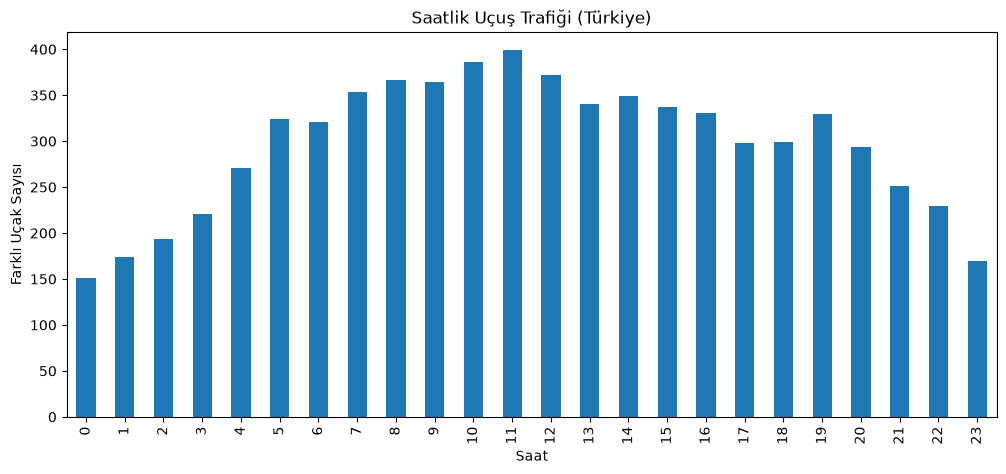

In [ ]:
#Grafik çizildi ve gösterildi
saatlik_trafik.plot(kind="bar", figsize=(12, 5), title="Saatlik Uçuş Trafiği (Türkiye)")
plt.xlabel("Saat")
plt.ylabel("Farklı Uçak Sayısı")
plt.show()

In [ ]:
#Uçakların saat 11:00 ve 03:00'teki konumları filtrelendi
df_11 = df_turkiye[df_turkiye["saat"] == 11]
df_03 = df_turkiye[df_turkiye["saat"] == 3]

# Her uçağın o saat içindeki SON konumu alınır (aynı uçak birden çok kez kaydedilmiş olabilir)
df_11_son = df_11.sort_values("time").drop_duplicates("icao24", keep="last")
df_03_son = df_03.sort_values("time").drop_duplicates("icao24", keep="last")

print(f"11:00 - {len(df_11_son)} farklı uçak")
print(f"03:00 - {len(df_03_son)} farklı uçak")

11:00 - 399 farklı uçak
03:00 - 221 farklı uçak


In [ ]:
#Uçakların irtifasına göre renk ataması yapan fonksiyon tanımlandı
def irtifa_renk(irtifa):
    if irtifa is None or pd.isna(irtifa):
        return "gray"
    elif irtifa < 1000:
        return "red"
    elif irtifa < 3000:
        return "orange"
    else:
        return "green"

In [ ]:
#Uçakların konumlarını ve irtifalarını gösteren harita oluşturma fonksiyonu tanımlandı
def harita_olustur(df, baslik):
    harita = folium.Map(location=[39.0, 35.0], zoom_start=6)
    folium.map.Marker(
        [42.5, 26.5],
        icon=folium.DivIcon(html=f'<div style="font-size: 16pt; font-weight: bold">{baslik}</div>')
    ).add_to(harita)

    for index, row in df.iterrows():
        renk = irtifa_renk(row["baroaltitude"])
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=5,
            popup=f"{row['callsign']} - {row['baroaltitude']}m",
            color=renk,
            fill=True,
            fill_color=renk
        ).add_to(harita)
    return harita

harita_yogun = harita_olustur(df_11_son, "Saat 11:00 - En Yoğun")
harita_sakin = harita_olustur(df_03_son, "Saat 03:00 - En Sakin")

In [ ]:
#Yoğun saatlerdeki uçuşların haritası gösterildi
harita_yogun

In [ ]:
#Sakin saatlerdeki uçuşların haritası gösterildi
harita_sakin

In [ ]:
#Uçuş Verilerinin istatistiksel özetleri yazdırıldı
print(df_turkiye["lat"].describe())
print(df_turkiye["lon"].describe())

count    897996.000000
mean         39.573737
std           1.734832
min          36.000009
25%          38.147743
50%          40.205566
75%          40.968155
max          42.000000
Name: lat, dtype: float64
count    897996.000000
mean         29.249617
std           1.833792
min          26.000000
25%          27.961337
50%          29.020074
75%          30.334875
max          36.539183
Name: lon, dtype: float64


C:\Users\pc\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


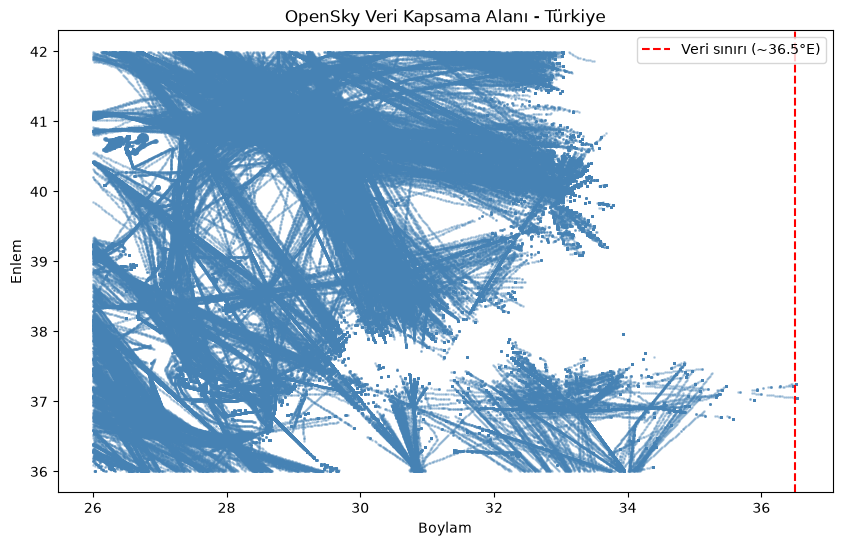

In [ ]:
#OpenSky veri kapsama alanı görselleştirildi
plt.figure(figsize=(10, 6))
plt.scatter(df_turkiye["lon"], df_turkiye["lat"], s=1, alpha=0.3, color="steelblue")
plt.xlabel("Boylam")
plt.ylabel("Enlem")
plt.title("OpenSky Veri Kapsama Alanı - Türkiye")
plt.axvline(x=36.5, color="red", linestyle="--", label="Veri sınırı (~36.5°E)")
plt.legend()
plt.show()

In [ ]:
#Uçuşların Havayolu Kodlarına Göre Dağılımı Yazdırıldı
print(df_turkiye["havayolu_kodu"].value_counts().head(10))

havayolu_kodu
THY    295427
PGT    109207
SXS     44553
CAI     21563
EXS     17108
QTR     15038
TB2     14678
RYR     14031
ELY     13539
TVS     12756
Name: count, dtype: int64


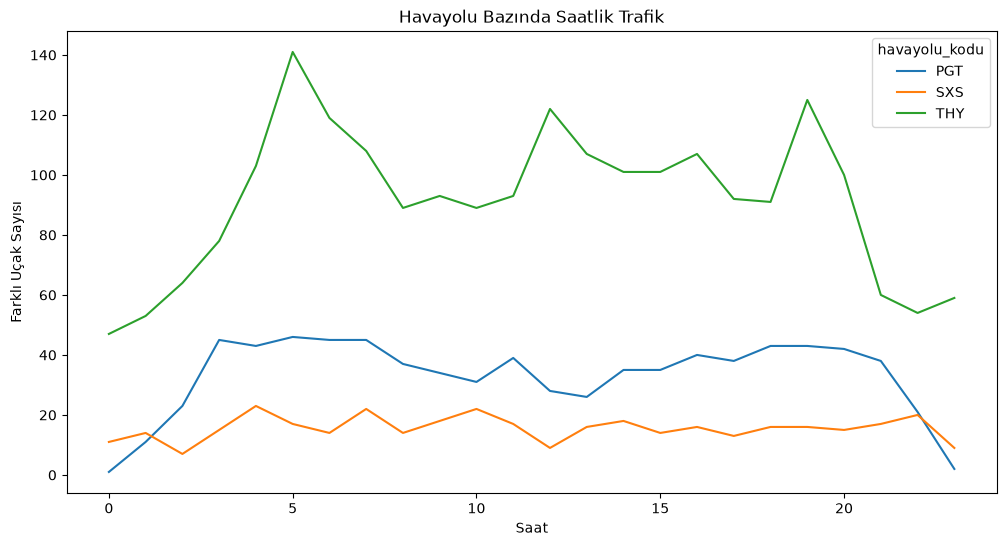

In [ ]:
#Uçuşların Havayolu Bazında Saatlik Trafiği Görselleştirildi
onemli_havayollari = ["THY", "PGT", "SXS"]

df_filtreli = df_turkiye[df_turkiye["havayolu_kodu"].isin(onemli_havayollari)]
saatlik_havayolu = df_filtreli.groupby(["saat", "havayolu_kodu"])["icao24"].nunique().unstack()

saatlik_havayolu.plot(kind="line", figsize=(12, 6), title="Havayolu Bazında Saatlik Trafik")
plt.xlabel("Saat")
plt.ylabel("Farklı Uçak Sayısı")
plt.show()

In [ ]:
#Acil durum sinyali veren uçuşları filtreleme ve yazdırma
acil_kodlar = [7500, 7600, 7700]  # 7500=kaçırma, 7600=iletişim kaybı, 7700=genel acil durum
df_turkiye["squawk"] = pd.to_numeric(df_turkiye["squawk"], errors="coerce")

acil_durumlar = df_turkiye[df_turkiye["squawk"].isin(acil_kodlar)]
print(f"Acil durum sinyali veren kayıt sayısı: {len(acil_durumlar)}")

if len(acil_durumlar) > 0:
    print(acil_durumlar[["callsign", "squawk", "time", "lat", "lon"]])

Acil durum sinyali veren kayıt sayısı: 0
